In [5]:
from langgraph.graph import StateGraph,START,END
from dotenv import load_dotenv
from langchain_groq import ChatGroq
from langchain_core.messages import BaseMessage
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import InMemorySaver
import os
from typing import TypedDict,Annotated,List

In [2]:
load_dotenv(dotenv_path=".env", override=True)
GROQ_API_KEY = os.getenv('GROQ_API_KEY')
model = ChatGroq(
    model="llama-3.3-70b-versatile",  
    api_key=GROQ_API_KEY  
)

In [4]:
class chatstate(TypedDict):
    messages:Annotated[list[BaseMessage],add_messages]

In [9]:
def chat(state:chatstate):
    messages=state['messages']
    response=model.invoke(messages)
    return{'messages':[response]}

In [10]:
graph=StateGraph(chatstate)
graph.add_node('chat',chat)
graph.add_edge(START,'chat')
graph.add_edge('chat',END)
checkpointer=InMemorySaver()
chatbot=graph.compile(checkpointer=checkpointer)

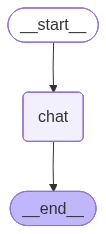

In [11]:
chatbot

In [13]:
config = {"configurable": {"thread_id": "thread-1"}}
config2 = {"configurable": {"thread_id": "thread-2"}}

In [12]:
chatbot.invoke({"messages": [{"role": "user", "content": "Hi! My name is Nitish."}]})

ValueError: Checkpointer requires one or more of the following 'configurable' keys: thread_id, checkpoint_ns, checkpoint_id